In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [17]:
# =========================================================
# CELL 1: IMPORT REQUIRED LIBRARIES
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


In [18]:
# =========================================================
# CELL 2: DEFINE CONFIGURATION PARAMETERS
# =========================================================

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15

DATASET_PATH = "/kaggle/input/datasets/vencerlanz09/agricultural-pests-image-dataset"


In [19]:
# =========================================================
# CELL 3: DATASET LOADING
# =========================================================

images = []
labels = []

class_names = sorted(os.listdir(DATASET_PATH))

for class_idx, class_name in enumerate(class_names):
    
    class_folder = os.path.join(DATASET_PATH, class_name)
    
    if os.path.isdir(class_folder):
        for img_name in os.listdir(class_folder):
            
            img_path = os.path.join(class_folder, img_name)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
                images.append(img)
                labels.append(class_idx)

images = np.array(images)
labels = np.array(labels)

print("Dataset Loaded Successfully")
print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)
print("Number of Classes:", len(class_names))


Dataset Loaded Successfully
Images Shape: (5494, 224, 224, 3)
Labels Shape: (5494,)
Number of Classes: 12


In [20]:
# =========================================================
# CELL 4: APPLY CLAHE IMAGE ENHANCEMENT
# =========================================================

def apply_clahe(image):
    
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    cl = clahe.apply(l)

    merged = cv2.merge((cl, a, b))
    return cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

processed_images = np.array([apply_clahe(img) for img in images])
processed_images = processed_images / 255.0

print("CLAHE Processing Completed")


CLAHE Processing Completed


In [21]:
# =========================================================
# CELL 5: TRAIN-VALIDATION SPLIT
# =========================================================

X_train, X_val, y_train, y_val = train_test_split(
    processed_images,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Training Samples:", X_train.shape[0])
print("Validation Samples:", X_val.shape[0])


Training Samples: 4395
Validation Samples: 1099


In [22]:
# =========================================================
# CELL 6: BUILD RESNET50 WITH FINE-TUNING
# =========================================================

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

# Freeze early layers, fine-tune deeper layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),  # Lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,612,300 (90.07 MB)

 Trainable params: 14,474,764 (55.22 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [23]:
# =========================================================
# CELL 7: TRAIN RESNET50 MODEL
# =========================================================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 50s 234ms/step - accuracy: 0.2115 - loss: 2.3301 - val_accuracy: 0.1538 - val_loss: 2.3301
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 141ms/step - accuracy: 0.3924 - loss: 1.8323 - val_accuracy: 0.3167 - val_loss: 2.1018
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 143ms/step - accuracy: 0.4337 - loss: 1.6987 - val_accuracy: 0.2702 - val_loss: 2.1530
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.4773 - loss: 1.5589 - val_accuracy: 0.3212 - val_loss: 2.2632
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.5022 - loss: 1.4889 - val_accuracy: 0.3885 - val_loss: 1.9364
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 139ms/step - accuracy: 0.5307 - loss: 1.3794 - val_accuracy: 0.4104 - val_loss: 1.8606
Epoch 7/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.5550 - loss: 1.3064 - val_accuracy: 0.3803 - val_loss: 2.0401
Epoch 8/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 140ms/step - accuracy: 0.5891 - loss: 1

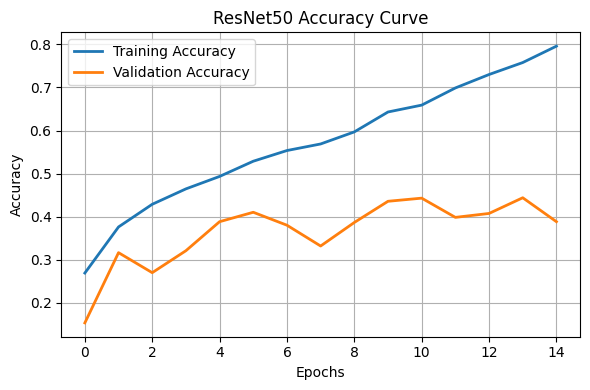

In [24]:
# =========================================================
# CELL 8: TRAINING & VALIDATION ACCURACY CURVE
# =========================================================

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], linewidth=2, label='Validation Accuracy')

plt.title("ResNet50 Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/resnet50_accuracy_curve.png", dpi=300)
plt.show()


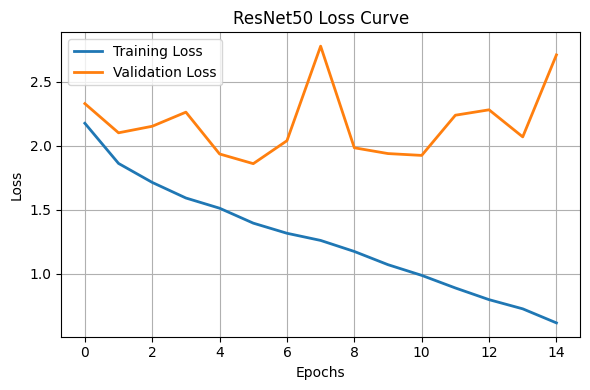

In [25]:
# =========================================================
# CELL 9: TRAINING & VALIDATION LOSS CURVE
# =========================================================

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], linewidth=2, label='Validation Loss')

plt.title("ResNet50 Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/resnet50_loss_curve.png", dpi=300)
plt.show()


In [26]:
# =========================================================
# CELL 10: FINAL MODEL PERFORMANCE
# =========================================================

train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("===== FINAL MODEL PERFORMANCE =====")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")


===== FINAL MODEL PERFORMANCE =====
Training Accuracy   : 0.7957
Validation Accuracy : 0.3885
Training Loss       : 0.6157
Validation Loss     : 2.7109


35/35 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step


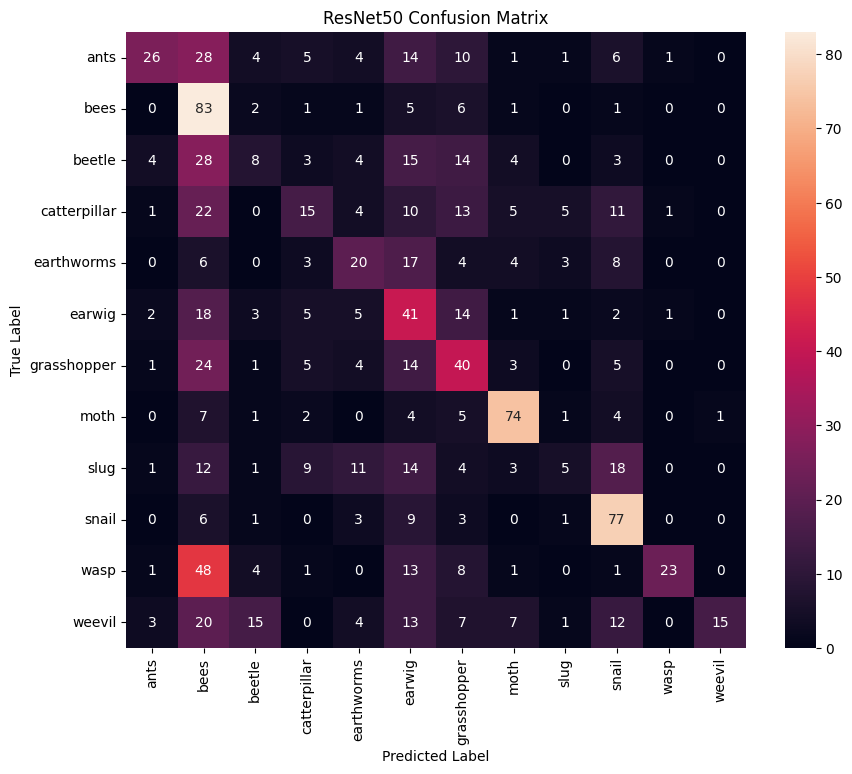

In [27]:
# =========================================================
# CELL 11: CONFUSION MATRIX
# =========================================================

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_val, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("ResNet50 Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()


In [28]:
# =========================================================
# CELL 12: CLASSIFICATION REPORT
# =========================================================

print(classification_report(y_val, y_pred_classes, target_names=class_names))


              precision    recall  f1-score   support

        ants       0.67      0.26      0.37       100
        bees       0.27      0.83      0.41       100
      beetle       0.20      0.10      0.13        83
catterpillar       0.31      0.17      0.22        87
  earthworms       0.33      0.31      0.32        65
      earwig       0.24      0.44      0.31        93
 grasshopper       0.31      0.41      0.36        97
        moth       0.71      0.75      0.73        99
        slug       0.28      0.06      0.10        78
       snail       0.52      0.77      0.62       100
        wasp       0.88      0.23      0.37       100
      weevil       0.94      0.15      0.27        97

    accuracy                           0.39      1099
   macro avg       0.47      0.37      0.35      1099
weighted avg       0.49      0.39      0.36      1099

